# 07 Feature Fusion: S2 + S1 Training Samples

**Author:** Florian Klaver

In this notebook the computed SAR features from the Sentinel-1 GRD and SLC product are attached to the already existing Sentinel-2 samples to create combined datasets.
Instead of re-running the full pixel sampling loop, the existing `training_samples_all_indices.csv` (which already contains `x`, `y` geographic coordinates in EPSG:2056) is reused and the S1 feature values are attached at those exact coordinates using `rasterio.sample()`.

### Feature sets

| Dataset | Features | Source |
|---|---|---|
| S2 features | 20 (5 indices × 4: after + diff, 5 raw bands × 2) | `training_samples_all_indices.csv` |
| GRD features | 6 (vv/vh/cr × after + diff) | `data/features_s1/<match_id>_s1_features.tif` |
| SLC features | 2 (coh_vv, coh_vh) | `data/features_coherence/<match_id>_coh<timestep>.tif` |


---
## 1. Setup

In [2]:
import sys
import os
import glob
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))
from src.config import *

S2_SAMPLES_PATH = SAMPLES_S2_CSV
FEATURES_S1_DIR = S1_FEATURES_DIR
COH_DIR = COH_DIR
FUSION_OUT_PATH = SAMPLES_FUSION_CSV    # SAR only (26 features)
COH_OUT_PATH = SAMPLES_FUSION_COH_CSV   # SAR + coherence (30 features)
TEMPORAL_MATCHES = TEMPORAL_MATCHES_CSV
IMG_DIR = DOCS_DIR

SAR_BAND_NAMES = ['vv_after', 'vh_after', 'cr_after', 'vv_diff', 'vh_diff', 'cr_diff']
COH_BAND_NAMES = ['coh_vv', 'coh_vh']    # per-sample coherence (period-matched)


s2_df = pd.read_csv(S2_SAMPLES_PATH)
print(f'S2 samples loaded:  {len(s2_df)} rows')
print(f'Columns:            {list(s2_df.columns)}')
print(f'Unique match_ids:   {s2_df["match_id"].nunique()}')
print(f'Class balance:      {s2_df["label"].value_counts().to_dict()}')

S2 samples loaded:  33368 rows
Columns:            ['x', 'y', 'event_date', 'match_id', 'label', 'ndvi_after', 'evi_after', 'savi_after', 'gndvi_after', 'ndii_after', 'ndvi_diff', 'evi_diff', 'savi_diff', 'gndvi_diff', 'ndii_diff', 'blue_diff', 'green_diff', 'red_diff', 'nir_diff', 'swir_diff', 'blue_after', 'green_after', 'red_after', 'nir_after', 'swir_after']
Unique match_ids:   63
Class balance:      {1: 18077, 0: 15291}


---
## 2. Check S1 Feature File Availability

In [3]:
# Discover which match_ids have S1 feature files on disk
s1_feature_files = glob.glob(os.path.join(FEATURES_S1_DIR, '*_s1_features.tif'))
available_match_ids = {
    int(os.path.basename(f).split('_')[0]) for f in s1_feature_files
}

all_match_ids = set(s2_df['match_id'].unique())
covered = all_match_ids & available_match_ids
missing = all_match_ids - available_match_ids

print(f'match_ids in S2 training CSV: {len(all_match_ids)}')
print(f'match_ids with GRD features:  {len(covered)}')
print(f'match_ids missing GRD:        {len(missing)}')

if missing:
    print(f'\nDropped match_ids: {sorted(missing)}')
    print('These events had no S1 coverage (no ascending IW image within ±3 days).')

match_ids in S2 training CSV: 63
match_ids with GRD features:  63
match_ids missing GRD:        0


---
## 3. Attach GRD Features to S2 Pixel Samples

For each match_id with an GRD feature file, `rasterio.DatasetReader.sample()` is used to look up the 6 SAR band values at the exact geographic `(x, y)` coordinates from the S2 training CSV.

In [4]:
# Work only on events that have GRD coverage
s2_covered = s2_df[s2_df['match_id'].isin(covered)].copy().reset_index(drop=True)
print(f'Pixel samples to enrich with SAR features: {len(s2_covered)}')

# Initialise SAR columns with NaN
for col in SAR_BAND_NAMES:
    s2_covered[col] = np.nan

n_processed = 0
n_nan_pixels = 0

# Loop over match_ids and sample SAR features at the S2 pixel coordinates
for match_id in sorted(covered):
    feat_path = os.path.join(FEATURES_S1_DIR, f'{match_id}_s1_features.tif')
    mask = s2_covered['match_id'] == match_id
    rows = s2_covered.loc[mask]

    if len(rows) == 0:
        continue

    coords = list(zip(rows['x'], rows['y']))  # list of (lon, lat) in EPSG:2056

    with rasterio.open(feat_path) as src:
        # sample() returns an iterator of arrays, one per coordinate, shape (n_bands,)
        sampled = np.array(list(src.sample(coords)))  # shape: (n_pixels, 6)

    # Replace nodata sentinel (NaN already used, but also check for extreme values)
    sampled = sampled.astype(np.float32)
    sampled[sampled < -60] = np.nan

    for i, col in enumerate(SAR_BAND_NAMES):
        s2_covered.loc[mask, col] = sampled[:, i]

    n_nan_pixels += np.isnan(sampled).any(axis=1).sum()
    n_processed  += len(rows)

print(f'Pixels processed:         {n_processed}')
print(f'Pixels with any NaN SAR:  {n_nan_pixels}  ({n_nan_pixels/n_processed*100:.1f}%)')
print('\nSAR feature statistics:')
print(s2_covered[SAR_BAND_NAMES].describe().round(3))

Pixel samples to enrich with SAR features: 33368
Pixels processed:         33368
Pixels with any NaN SAR:  0  (0.0%)

SAR feature statistics:
        vv_after   vh_after   cr_after    vv_diff    vh_diff    cr_diff
count  33368.000  33368.000  33368.000  33368.000  33368.000  33368.000
mean     -13.723    -19.844     -6.121     -0.512     -0.295      0.217
std        1.607      1.505      1.380      1.794      1.562      1.653
min      -18.585    -24.455    -18.321    -18.752     -6.491     -7.559
25%      -14.752    -20.881     -6.959     -1.714     -1.305     -0.785
50%      -13.852    -19.928     -6.057     -0.570     -0.215      0.211
75%      -12.828    -18.894     -5.207      0.579      0.761      1.271
max        0.261     -7.295     -1.275      7.199      8.113     15.567


---
## 4. Attach Coherence Features

### Feature design rationale

The existing S2 and GRD features follow a **per-sample, period-matched** design:

| Sample type | Period | Example feature |
|------------|--------|-----------------|
| Positive (mowed, label=1) | t2 → t3 | `ndvi_diff` = NDVI(t3) − NDVI(t2) |
| Negative (not mowed, label=0) | t1 → t2 | `ndvi_diff` = NDVI(t2) − NDVI(t1) |

Each sample type receives feature values from **its own time interval**, giving the model per-pixel discriminative signal (mowed pixels show a large NDVI drop, unmowed do not).

Coherence must follow the same logic, but it uses 4 timesteps instead of 3:

| Sample type | Coherence image | Feature assigned |
|------------|----------------|-----------------|
| Positive (mowed, label=1) | coh(t3, t4): `coh_after` | `coh_vv`, `coh_vh` = values from `coh_after.tif` |
| Negative (not mowed, label=0) | coh(t1, t2): `coh_before` | `coh_vv`, `coh_vh` = values from `coh_before.tif` |



**2 coherence features in total:**
- `coh_vv`, `coh_vh`: per-sample VV/VH coherence for that sample's own time interval

With this design the model learns somethign slightly different for coherence than for S2. For S2 it learned the difference between two images, differentiating between no change vs change in specific numerical values of vegetation indices (e.g. NDII). For coherence it is slightly different. Since coherence already describes a "stability" between two images of different timesteps we ratehr compare if the grass is short or long. Similar approach but small difference in the logic. Using two additional SLC images per event (6) would enable computing an additional feature (coherence-jump) for both labels. This could grant slightly better results based on the logic of the feature, but means even more constraint for getting valid data and more computational cost.


In [5]:
def _find_coh_bands(src):
    """
    Return (vv_idx, vh_idx) as 1-based band indices for coherence bands.
    SNAP's GeoTIFF writer omits band descriptions, so fall back to a multi-region
    value-range scan: coherence is always in [0, 1]; interferogram bands are not.
    """
    descs = src.descriptions or []
    named = [(i + 1, d) for i, d in enumerate(descs) if d and 'coh' in d.lower()]
    vv = next((i for i, d in named if 'vv' in d.lower()), None)
    vh = next((i for i, d in named if 'vh' in d.lower()), None)
    if vv is not None:
        return vv, vh

    h, w, sz = src.height, src.width, 200
    wins = [
        rasterio.windows.Window(0, 0, min(sz, w), min(sz, h)),
        rasterio.windows.Window(max(0, w // 2 - sz // 2), max(0, h // 2 - sz // 2), min(sz, w), min(sz, h)),
        rasterio.windows.Window(max(0, w - sz), max(0, h - sz), min(sz, w), min(sz, h)),
    ]
    coh_idx = []
    for band in range(1, src.count + 1):
        ok = True
        for win in wins:
            arr   = src.read(band, window=win).astype(float)
            valid = arr[(arr != 0) & np.isfinite(arr)]
            if valid.size > 50 and (valid.max() > 1.0 or valid.min() < 0.0):
                ok = False
                break
        if ok:
            coh_idx.append(band)
    if len(coh_idx) >= 2:
        return coh_idx[0], coh_idx[1]
    if len(coh_idx) == 1:
        return coh_idx[0], None
    return 1, (2 if src.count >= 2 else None)


# ── Discover available coherence pairs ───────────────────────────────────────
coh_before_ids = {int(os.path.basename(f).split('_')[0])
                  for f in glob.glob(os.path.join(COH_DIR, '*_coh_before_snrcorr.tif'))}
coh_after_ids  = {int(os.path.basename(f).split('_')[0])
                  for f in glob.glob(os.path.join(COH_DIR, '*_coh_after_snrcorr.tif'))}
coh_available  = coh_before_ids & coh_after_ids

n_all = s2_covered['match_id'].nunique()
print(f'Events with both coherence rasters on disk: {len(coh_available)} / {n_all}')
print(f'Events without coherence (will be NaN):     {n_all - len(coh_available)}')

# Initialise coherence columns with NaN
for col in COH_BAND_NAMES:
    s2_covered[col] = np.nan

n_coh_ok = 0

for match_id in sorted(coh_available):
    before_path = os.path.join(COH_DIR, f'{match_id}_coh_before_snrcorr.tif')
    after_path  = os.path.join(COH_DIR, f'{match_id}_coh_after_snrcorr.tif')

    mask = s2_covered['match_id'] == match_id
    rows = s2_covered.loc[mask]
    if len(rows) == 0:
        continue

    coords = list(zip(rows['x'], rows['y']))

    # Sample both rasters at every pixel coordinate
    with rasterio.open(before_path) as bs:
        vv_b, vh_b = _find_coh_bands(bs)
        coh_b = np.array(list(bs.sample(coords))).astype(float)
    with rasterio.open(after_path) as as_:
        vv_a, vh_a = _find_coh_bands(as_)
        coh_a = np.array(list(as_.sample(coords))).astype(float)

    # Extract VV and VH from each raster (convert 1-based idx to 0-based column)
    b_vv = coh_b[:, vv_b - 1].copy()
    b_vh = coh_b[:, vh_b - 1].copy() if vh_b else np.full(len(rows), np.nan)
    a_vv = coh_a[:, vv_a - 1].copy()
    a_vh = coh_a[:, vh_a - 1].copy() if vh_a else np.full(len(rows), np.nan)

    # Replace SNAP nodata (0 for pixels outside SAR coverage)
    for arr in [b_vv, b_vh, a_vv, a_vh]:
        arr[arr <= 0] = np.nan

    labels = rows['label'].values

    # Period-matched coherence (quadruplet design):
    #   label=1 (mowed)     -> coh_after  (post-mowing stability, expected HIGH)
    #   label=0 (not mowed) -> coh_before (pre-mowing instability, expected LOW)
    s2_covered.loc[mask, 'coh_vv'] = np.where(labels == 1, a_vv, b_vv)
    s2_covered.loc[mask, 'coh_vh'] = np.where(labels == 1, a_vh, b_vh)

    n_coh_ok += len(rows)

print(f'\nPixels enriched with coherence: {n_coh_ok}')
if n_coh_ok > 0:
    coh_rows = s2_covered[s2_covered['coh_vv'].notna()]
    print('\nCoherence feature stats:')
    print(coh_rows[COH_BAND_NAMES].describe().round(3))
    print('\nMean by class (label 1=mowed, 0=not mowed):')
    print(coh_rows.groupby('label')[COH_BAND_NAMES].mean().round(3))

Events with both coherence rasters on disk: 36 / 63
Events without coherence (will be NaN):     27

Pixels enriched with coherence: 15311

Coherence feature stats:
          coh_vv     coh_vh
count  15311.000  15311.000
mean       0.281      0.387
std        0.149      0.198
min        0.013      0.019
25%        0.167      0.231
50%        0.260      0.367
75%        0.375      0.522
max        1.000      1.000

Mean by class (label 1=mowed, 0=not mowed):
       coh_vv  coh_vh
label                
0       0.286   0.389
1       0.277   0.385


In [19]:
coh_valid = s2_covered[s2_covered['coh_vv'].notna()]
print(f"Unique match_ids with valid coherence: {coh_valid['match_id'].nunique()}")
print(f"Match_ids WITH coherence: {sorted(coh_valid['match_id'].unique())}")
missing = set(coh_available) - set(coh_valid['match_id'].unique())
print(f"Match_ids with TIF but zero valid samples: {sorted(missing)}")

Unique match_ids with valid coherence: 24
Match_ids WITH coherence: [np.int64(12), np.int64(39), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(50), np.int64(51), np.int64(59), np.int64(62), np.int64(63), np.int64(64), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78)]
Match_ids with TIF but zero valid samples: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 21]


These additional scenes which are lost (from 36 down to 24) have to be discarded because there are no valid S2 samples for those match ids due to too high cloud coverage

---
## 5. Drop Rows with NaN SAR Features

Pixels where the GRD S1 raster has nodata must be dropped.

Coherence NaNs are **not** dropped here. Notebook 08 will select only the coherence-eligible subset for the coherence ablation configs.

In [6]:
before_drop = len(s2_covered)
fusion_df = s2_covered.dropna(subset=SAR_BAND_NAMES).reset_index(drop=True)
after_drop = len(fusion_df)

print(f'Before NaN drop: {before_drop} rows')
print(f'After NaN drop:  {after_drop} rows  ({before_drop - after_drop} dropped)')
print(f'Retained:        {after_drop/before_drop*100:.1f}%')
print()
print(f'Final class balance: {fusion_df["label"].value_counts().to_dict()}')
print(f'Events covered:      {fusion_df["match_id"].nunique()}')

Before NaN drop: 33368 rows
After NaN drop:  33368 rows  (0 dropped)
Retained:        100.0%

Final class balance: {1: 18077, 0: 15291}
Events covered:      63


---
## 6. Save Fusion Datasets

Two files are written:
- **`training_samples_fusion.csv`** — 26 features (S2 + GRD SAR)
- **`training_samples_fusion_coh.csv`** — 28 features (above + 2 coherence)

In [7]:
# Save backwards-compatible SAR fusion (drop coherence columns so nb05 existing runs are unaffected)
sar_cols = [c for c in fusion_df.columns if c not in COH_BAND_NAMES]
fusion_df[sar_cols].to_csv(FUSION_OUT_PATH, index=False)
print(f'Saved (SAR fusion):')
print(f'  Path:    {FUSION_OUT_PATH}')
print(f'  Rows:    {len(fusion_df)}')
print(f'  Columns: {sar_cols}')

# Save coherence-extended fusion
fusion_df.to_csv(COH_OUT_PATH, index=False)
coh_cols = list(fusion_df.columns)
print(f'\nSaved (coherence fusion):')
print(f'  Path:    {COH_OUT_PATH}')
print(f'  Rows:    {len(fusion_df)}')
print(f'  Columns ({len(coh_cols)}): {coh_cols}')
n_with_coh = fusion_df['coh_vv'].notna().sum()
print(f'\n  Rows with coherence data: {n_with_coh} / {len(fusion_df)} '
      f'({n_with_coh/len(fusion_df)*100:.1f}%)')

Saved (SAR fusion):
  Path:    C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\training_samples_fusion.csv
  Rows:    33368
  Columns: ['x', 'y', 'event_date', 'match_id', 'label', 'ndvi_after', 'evi_after', 'savi_after', 'gndvi_after', 'ndii_after', 'ndvi_diff', 'evi_diff', 'savi_diff', 'gndvi_diff', 'ndii_diff', 'blue_diff', 'green_diff', 'red_diff', 'nir_diff', 'swir_diff', 'blue_after', 'green_after', 'red_after', 'nir_after', 'swir_after', 'vv_after', 'vh_after', 'cr_after', 'vv_diff', 'vh_diff', 'cr_diff']

Saved (coherence fusion):
  Path:    C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\training_samples_fusion_coh.csv
  Rows:    33368
  Columns (33): ['x', 'y', 'event_date', 'match_id', 'label', 'ndvi_after', 'evi_after', 'savi_after', 'gndvi_after', 'ndii_after', 'ndvi_diff', 'evi_diff', 'savi_diff', 'gndvi_diff', 'ndii_diff', 'blue_diff', 'green_diff', 'red_diff', 'nir_diff', 'swir_diff', 'blue_after', 'green_after', 'red_after', 'nir_after', 'swir

---
## 6. Quick Feature Distribution Check for GRD

Sanity-check that SAR features separate mowed vs. not-mowed samples in the expected direction:
- `vh_diff` should be **more negative** for mowed pixels (VH drops after mowing)
- `cr_diff` should be **more negative** for mowed pixels (CR drops after mowing)

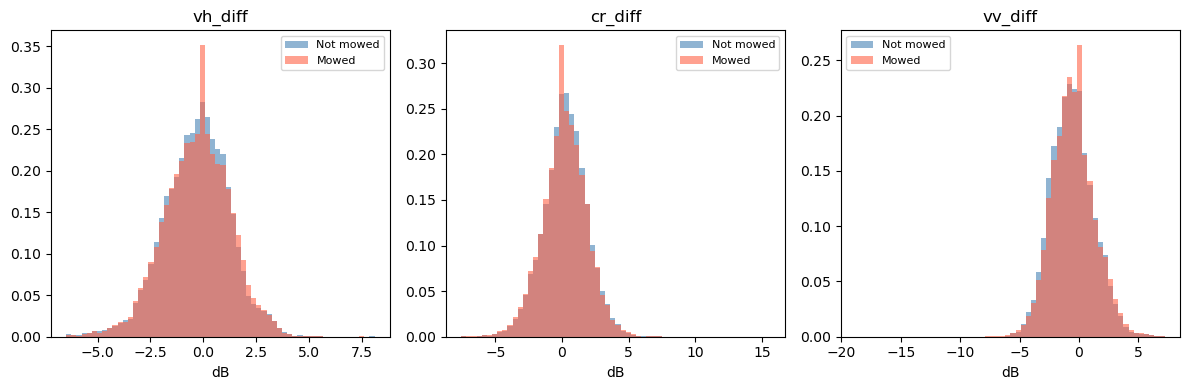

Expected: vh_diff and cr_diff should be shifted negative for mowed pixels.

Mean values by class:
       vh_diff  cr_diff  vv_diff
label                           
0       -0.309    0.246   -0.555
1       -0.284    0.191   -0.475


In [17]:
mowed     = fusion_df[fusion_df['label'] == 1]
not_mowed = fusion_df[fusion_df['label'] == 0]

key_features = ['vh_diff', 'cr_diff', 'vv_diff']

fig, axes = plt.subplots(1, len(key_features), figsize=(12, 4))

for ax, feat in zip(axes, key_features):
    ax.hist(not_mowed[feat].dropna(), bins=60, alpha=0.6, label='Not mowed', color='steelblue', density=True)
    ax.hist(mowed[feat].dropna(),     bins=60, alpha=0.6, label='Mowed',     color='tomato',    density=True)
    ax.set_title(feat)
    ax.set_xlabel('dB')
    ax.legend(fontsize=8)

# plt.suptitle('SAR feature distributions: mowed vs. not mowed', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'GRD_feature_distributions.png'), dpi=300)
plt.show()

print('Expected: vh_diff and cr_diff should be shifted negative for mowed pixels.')
print('\nMean values by class:')
print(fusion_df.groupby('label')[key_features].mean().round(3))

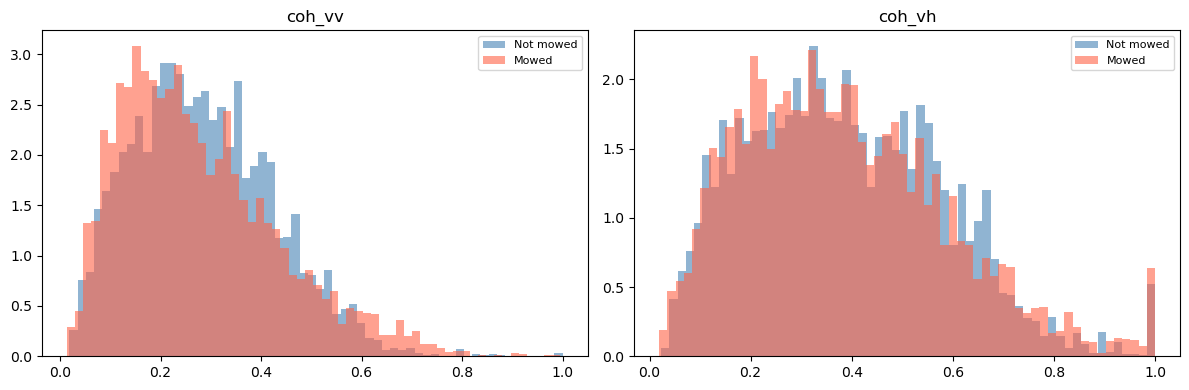

In [18]:
mowed     = fusion_df[fusion_df['label'] == 1]
not_mowed = fusion_df[fusion_df['label'] == 0]

key_features = ['coh_vv', 'coh_vh']

fig, axes = plt.subplots(1, len(key_features), figsize=(12, 4))

for ax, feat in zip(axes, key_features):
    ax.hist(not_mowed[feat].dropna(), bins=60, alpha=0.6, label='Not mowed', color='steelblue', density=True)
    ax.hist(mowed[feat].dropna(),     bins=60, alpha=0.6, label='Mowed',     color='tomato',    density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)

# plt.suptitle('SAR feature distributions: mowed vs. not mowed', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'Coherence_feature_distributions.png'), dpi=300)
plt.show()


---
#### Outputs:

`data/training_samples_fusion.csv` — 26 features (20 S2 + 6 GRD SAR)

`data/training_samples_fusion_coh.csv` — 28 features (above + 2 coherence)
- Adds `coh_vv`, `coh_vh` (per-sample, period-matched coherence)
- Events without coherence rasters on disk have NaN in these columns
